In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import torch
import compress_pickle
import matplotlib.pyplot as plt
import numpy as np
sys.path.append('..')
import hippocampalseq as hse
import hippocampalseq.preprocessing as hsep
import hippocampalseq.models as hsem 
import hippocampalseq.utils as hseu

torch.set_default_dtype(torch.double)
time_window_ms = 2

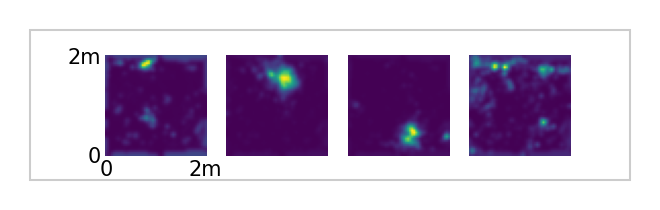

In [58]:
hse.init_plotting()
rat_data = hsep.load_and_preprocess(
    os.path.realpath("../data"),
    "Harpy",
    2,
    time_window_ms=time_window_ms
)
hse.plot_placefields(rat_data.place_field_data, [0,1,2,3])

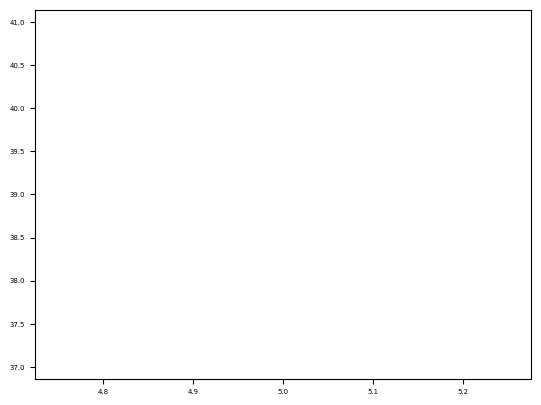

In [59]:
bmap = hsem.BayesianMAP(
    rat_data.place_field_data.place_fields,#[rat_data.place_field_data.place_cell_ids],
    time_window_ms
)
bmap_traj = bmap.fit([s.spikemat for s in rat_data.ripple_data.ripple_spikes]).trajectories
plt.plot(bmap_traj[20][:,0], bmap_traj[20][:,1])

(132, 50, 50)

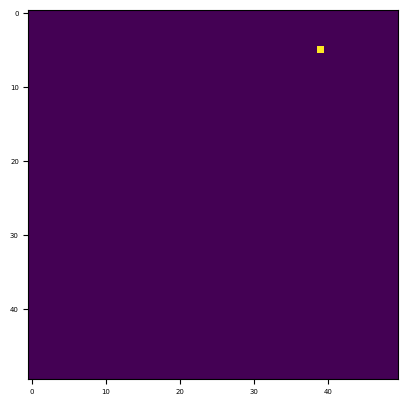

In [61]:
ep = hseu.calc_poisson_emission_probabilities_2d(
    rat_data.ripple_data.ripple_spikes[1].spikemat,
    rat_data.place_field_data.place_fields,#[rat_data.place_field_data.place_cell_ids],
    time_window_ms
)
plt.imshow(ep[10])
ep.shape

In [6]:
hse.init_plotting()

for rat_name in hsep.RAT_NAMES:
    for session in [1, 2]:
        rat_data = hsep.load_and_preprocess(
            os.path.realpath("../data"), 
            rat_name, 
            session,
            time_window_ms=time_window_ms
        )
        hse.plot_placefields(rat_data.place_field_data.place_fields, [0,1,2,3])
        hseu.save_pickle(rat_data, f"../data/{rat_name}-{session}.pkl")

KeyboardInterrupt: 

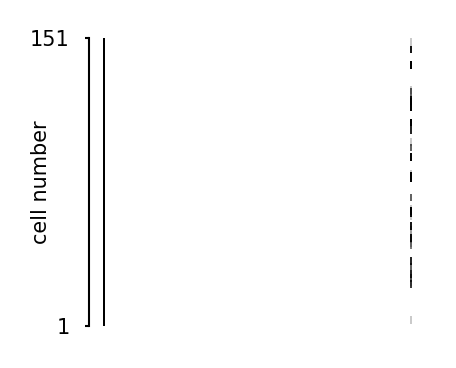

In [64]:
hse.spike_raster_plot(rat_data.theta_data.theta_spikes[0].spikemat.T)

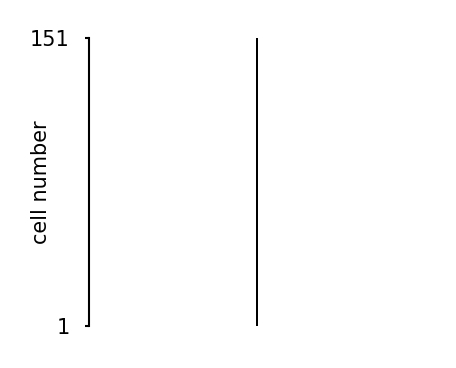

In [62]:
hse.spike_raster_plot(rat_data.ripple_data.ripple_spikes[3].spikemat.T)

In [ ]:
m = hsem.Momentum(
    rat_data.place_field_data.place_fields[rat_data.place_field_data.place_cell_ids], 
    rat_data.ripple_data.spikemats_ripple,
    time_window_ms / 1000,
    (50, 50),
    seed=None
)


FileNotFoundError: [Errno 2] No such file or directory: './data/momentum.pkl'

In [63]:
s = compress_pickle.dumps(m, "gzip")
with open("../data/momentum.pkl", "wb") as f:
    f.write(s)

In [3]:
with open("../data/momentum.pkl", "rb") as f:
    raw = f.read()
    m = compress_pickle.loads(raw, "gzip")

In [31]:
m.decay = torch.rand(1)
m.diffusion = torch.rand(1)
m.initial_diffusion = 10

In [32]:
fm = m.em(n_iter=100000, emtol=1e-3, lr=0.1, seed=None, gd_tol=1e-3)

Converged after 316 epochs, exiting


In [35]:
m.decay, m.diffusion, m.initial_diffusion

(tensor([1377.0619]), tensor([-17294.5531]), tensor([258.7948]))

tensor(46.3921) tensor(1.6110)
(tensor(1), tensor(1), tensor(0)) (tensor(28), tensor(1), tensor(0))


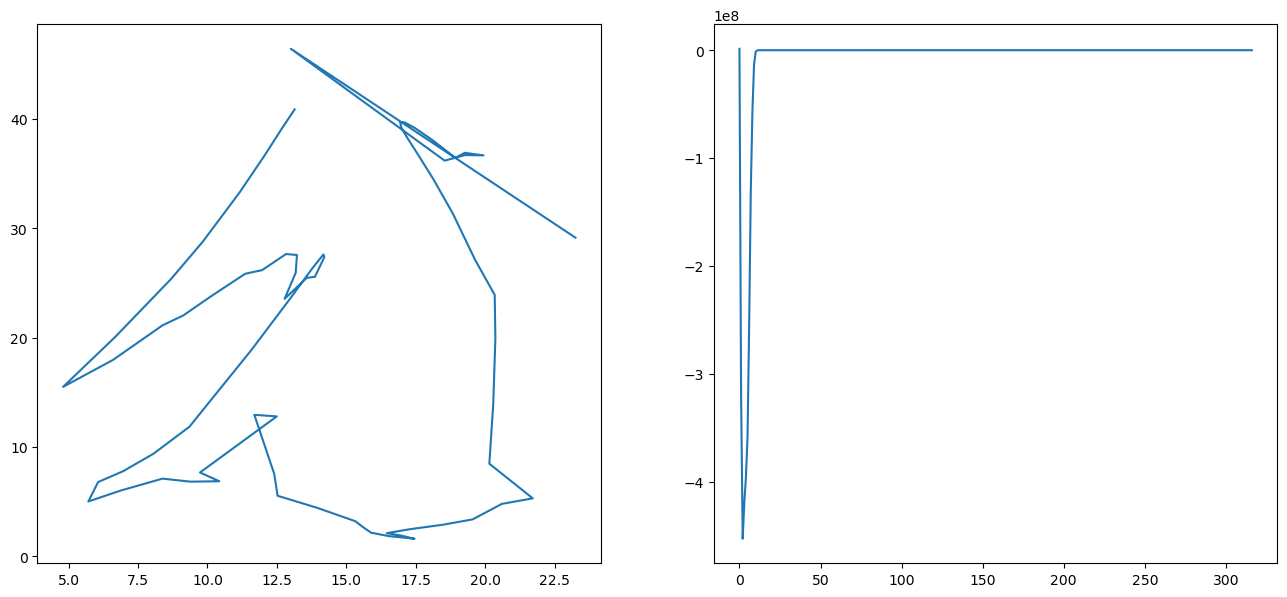

In [37]:
t = fm[0][78]['kf_results'].smoothed_mean[:,:2]
plt.figure(figsize=(16,7))
plt.subplot(1,2,1)
plt.plot(t[:,0], t[:,1])
plt.subplot(1,2,2)
plt.plot(fm[2])
print(t.max(), t.min())
print(
    torch.unravel_index(t.argmax(), t.shape),
    torch.unravel_index(t.argmin(), t.shape)
)

In [34]:
fm[2]

[tensor(1300022.6023),
 tensor(-3.1854e+08),
 tensor(-4.5276e+08),
 tensor(-4.1922e+08),
 tensor(-3.9527e+08),
 tensor(-3.5730e+08),
 tensor(-2.5253e+08),
 tensor(-1.2896e+08),
 tensor(-56410485.5775),
 tensor(-13419262.0930),
 tensor(-1495828.3579),
 tensor(-148012.4384),
 tensor(-49690.7833),
 tensor(-29992.5821),
 tensor(-28243.8052),
 tensor(-27820.7986),
 tensor(-27701.0006),
 tensor(-27586.3793),
 tensor(-27475.1233),
 tensor(-27367.5783),
 tensor(-27263.9788),
 tensor(-27164.4523),
 tensor(-27069.0332),
 tensor(-26977.6794),
 tensor(-26890.2887),
 tensor(-26806.7151),
 tensor(-26726.7821),
 tensor(-26650.2937),
 tensor(-26577.0434),
 tensor(-26506.8214),
 tensor(-26439.4189),
 tensor(-26374.6328),
 tensor(-26312.2674),
 tensor(-26252.1367),
 tensor(-26194.0652),
 tensor(-26137.8886),
 tensor(-26083.4536),
 tensor(-26030.6182),
 tensor(-25979.2513),
 tensor(-25929.2319),
 tensor(-25880.4491),
 tensor(-25832.8014),
 tensor(-25786.1956),
 tensor(-25740.5470),
 tensor(-25695.7782),


In [ ]:
from scipy.stats import multivariate_normal, norm
import ipywidgets as widgets
from ipywidgets import interact,fixed,interactive
import hippocampalseq.utils as hseu

def plot_emission_prob(ep, kl):
    dz = 1.0
    x = np.arange(ep.shape[1])
    y = np.arange(ep.shape[0])
    X,Y = np.meshgrid(x,y)

    pz = (ep / np.sum(ep)).reshape(X.shape)

    idxmax = np.unravel_index(np.argmax(pz), pz.shape)

    #fig, ax = plt.subplots(2,2, figsize=(12,10))
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax = ax.ravel()
    cs = ax[0].contourf(X, Y, pz, cmap='viridis')
    ax[0].scatter(idxmax[1], idxmax[0], s=1.0, c='red')
    ax[0].set_xlabel('X')
    ax[0].set_ylabel('Y')
    ax[0].set_title('Contour Plot of Emission Probability')
    fig.colorbar(cs)

    z = hseu.bin_points(x, y)
    #Ez,Vz,Zt = hseu.calc_normal_params(z, pz.ravel(), dz)
    Ez,Vz = hseu.laplacian_approximation(torch.from_numpy(z), torch.from_numpy(pz), kl)

    print(Ez)
    print(Vz)
    #print(Zt)

    ax[0].scatter(Ez[0], Ez[1], s=1.0, c='blue')

    mvn = multivariate_normal(mean=Ez.squeeze(), cov=Vz)
    Z = mvn.pdf(np.column_stack((X.ravel(), Y.ravel())))
    Z = Z.reshape(X.shape) / np.sum(Z)

    cs1 = ax[1].contourf(X,Y,Z, cmap='viridis')
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('Y')
    ax[1].set_title('Contour Plot of Gaussian Approximating Poisson Emission')
    fig.colorbar(cs1)

    """
    marginal_x = np.sum(pz, axis=0)
    #Ez,Vz,_ = hseu.calc_normal_params(x[:,None], marginal_x, dz)
    Ez,Vz = hseu.laplacian_approximation(torch.from_numpy(x), torch.from_numpy(marginal_x), kl)
    Px = norm(Ez, Vz).pdf(x)
    Px /= np.sum(Px)
    print(Ez)
    print(Vz)
   
    ax[2].plot(marginal_x)
    ax[2].plot(Px.ravel(), c='orange')
    ax[2].set_title('Marginal Distribution Over X')

    marginal_y = np.sum(pz, axis=1)
    #Ez,Vz,Zt = hseu.calc_normal_params(y[:,None], marginal_y, dz)
    Ez,Vz = hseu.laplacian_approximation(torch.from_numpy(y), torch.from_Numpy(marginal_y), kl)
    Py = norm(Ez, Vz).pdf(y) 
    Py /= np.sum(Py)
    print(Ez)
    print(Vz)

    ax[3].plot(marginal_y)
    ax[3].plot(Py.ravel(), c='orange')
    ax[3].set_title('Marginal Distribution over Y')
    """

def display_likelihood(n, t, kl):
    spikemat = rat_data.ripple_data.spikemats_ripple[n]
    pfs = rat_data.place_field_data.place_fields[rat_data.place_field_data.place_cell_ids]
    ek = hseu.calc_poisson_emission_probabilities_2d(
        spikemat,
        pfs,
        hsep.PFEIFFER_RECORDING_FPS
    )
    plot_emission_prob(ek[t], kl)

c1 = widgets.IntSlider(
    value=0, 
    min=0, 
    max=len(rat_data.ripple_data.spikemats_ripple),
    continuous_update=False
)
c2 = widgets.IntSlider(
    value=0, 
    min=0, 
    max=1,
    continuous_update=False
)
kl = widgets.Dropdown(
    options=['pq', 'qp'],
    descripion="KL-divergence"
)

def update_slider(x):
    c2.max = len(rat_data.ripple_data.spikemats_ripple[c1.value])

c1.observe(update_slider)

i_control = interactive(display_likelihood, n=c1, t=c2, kl=kl)
i_control
